In [7]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

In [25]:
# Load your Excel sheet
df = pd.read_csv("~/DSP_group_project_avian_datasets/data/raw/colour/Data_S1/RGB_values_for_color_classification.csv") 

color_order = [f'color{i}' for i in range(1, 25)]
df['Color classification'] = pd.Categorical(df['Color classification'], categories=color_order, ordered=True)
df = df.sort_values('Color classification')

In [8]:
def show_color_patches(df):
    n = len(df)
    fig, axes = plt.subplots(n, 1, figsize=(5, n*1.5))
    
    if n == 1:
        axes = [axes]

    for ax, (_, row) in zip(axes, df.iterrows()):
        # Clip RGB to 0-255 and normalize
        r = np.clip(row['R'], 0, 255) / 255
        g = np.clip(row['G'], 0, 255) / 255
        b = np.clip(row['B'], 0, 255) / 255
        color = (r, g, b)
        
        # Draw rectangle
        ax.add_patch(plt.Rectangle((0, 0), 1, 1, color=color))
        ax.set_xlim(0, 1)
        ax.set_ylim(0, 1)
        ax.axis('off')
        
        # Add text
        ax.text(0.5, -0.3, f"{row['Color classification']} - {row['Colors']}", 
                ha='center', va='top', fontsize=12)

    plt.tight_layout()
    plt.show()


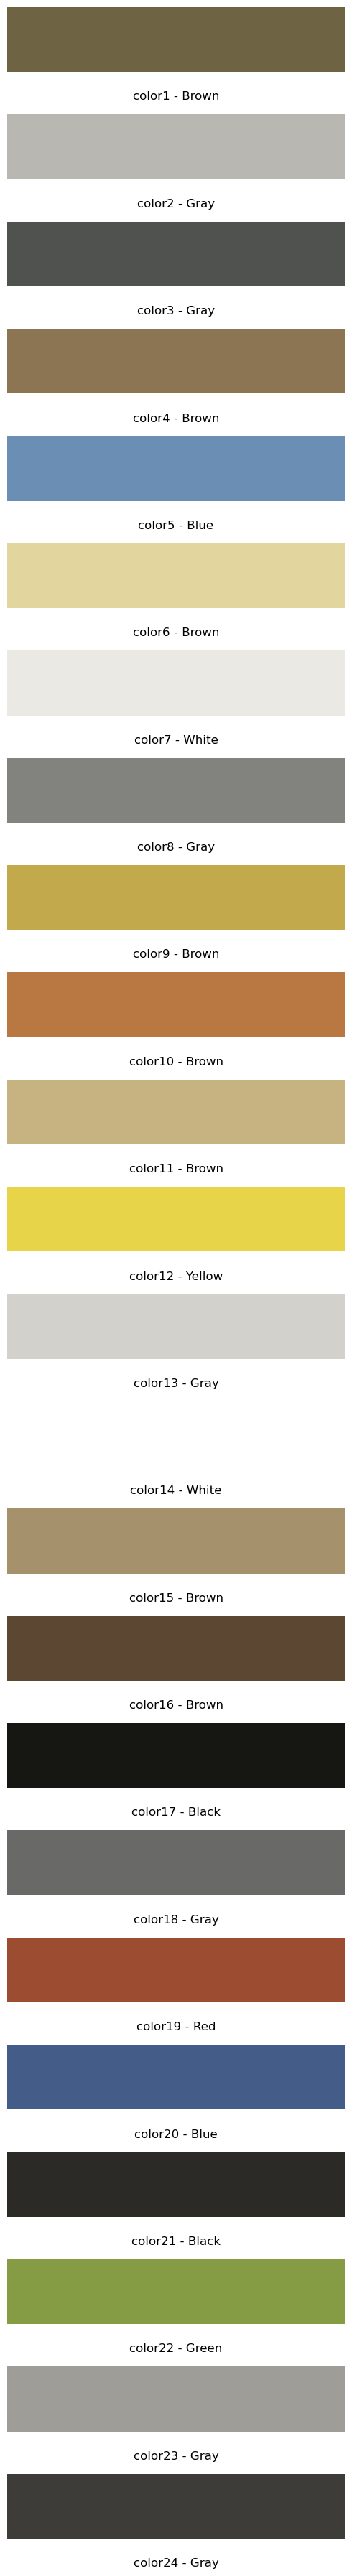

In [13]:

# Display
show_color_patches(df)

In [35]:
# Load your CSV
df2 = pd.read_csv("/home/anagha/DSP_group_project_avian_datasets/data/raw/colour/Data_S1/Information_for_Illustrations_and_proportion_of_24_colors.csv")

# Suppose you want the top 10 colors for a given species
species_name = "Bee Hummingbird"  # replace with the Com_name you want

# Select the row for that species
row = df2[df2['Com_name'] == species_name]

# Extract the color columns
color_cols = [f'color{i}' for i in range(1, 25)]
colors = row[color_cols].iloc[0]

# Sort colors by proportion (descending) and take top 10
top10_colors = colors.sort_values(ascending=False).head(13)

print(top10_colors)

color14    0.184
color13    0.108
color18    0.094
color2     0.093
color3     0.092
color21    0.086
color7     0.082
color24    0.071
color8     0.055
color23    0.037
color20    0.032
color17    0.019
color22    0.014
Name: 10135, dtype: float64


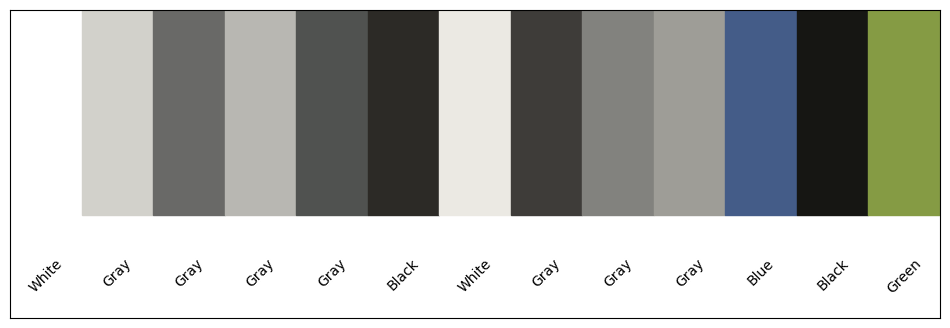

In [36]:
top_colors = top10_colors.index.tolist()  # ['color19', 'color10', ...]

fig, ax = plt.subplots(figsize=(12, 4))

for i, color_name in enumerate(top_colors):
    # Get the row corresponding to the color
    row = df[df['Color classification'] == color_name].iloc[0]
    
    # Convert RGB to 0-1 range
    rgb = [row['R']/255, row['G']/255, row['B']/255]
    
    # Clip values just in case some are slightly >1
    rgb = [min(max(c,0),1) for c in rgb]
    
    ax.add_patch(plt.Rectangle((i, 0), 1, 1, color=rgb))
    ax.text(i + 0.5, -0.2, row['Colors'], ha='center', va='top', fontsize=10, rotation=45)

ax.set_xlim(0, len(top_colors))
ax.set_ylim(-0.5, 1)
ax.set_xticks([])
ax.set_yticks([])
plt.show()

In [24]:
print(df.columns.tolist())

['eBird species code 2019', 'Com_name', 'Sci_name', 'Subspecies', 'Illustration_id', 'Credit', 'Sex', 'Age', 'Morph', 'Order', 'Family', 'Group', 'color1', 'color2', 'color3', 'color4', 'color5', 'color6', 'color7', 'color8', 'color9', 'color10', 'color11', 'color12', 'color13', 'color14', 'color15', 'color16', 'color17', 'color18', 'color19', 'color20', 'color21', 'color22', 'color23', 'color24']
